# 03 — Multivariate Analysis
**FoodHub Order Analysis**

This notebook examines **three or more variables together** to surface interactions
the univariate and bivariate views cannot show. As before, **no statistical
hypothesis testing is performed here** — exploratory visualizations only.

Focus areas (still framed by the three hypotheses):
- **H1** — fulfillment time by day type *and* cuisine (does weekend effect depend on cuisine?)
- **H2** — rating vs fulfillment time *conditioned on* day type / cost band
- **H3** — cost x volume x cuisine, and how the numeric measures co-move

Data: `../data/processed/foodhub_analytical_clean.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv("../data/processed/foodhub_analytical_clean.csv")
print("Shape:", df.shape)

Shape: (1898, 23)


## 1. Correlation heatmap of numeric measures
How do the continuous variables co-move? (cost, prep, delivery, total time, and
numeric rating.)

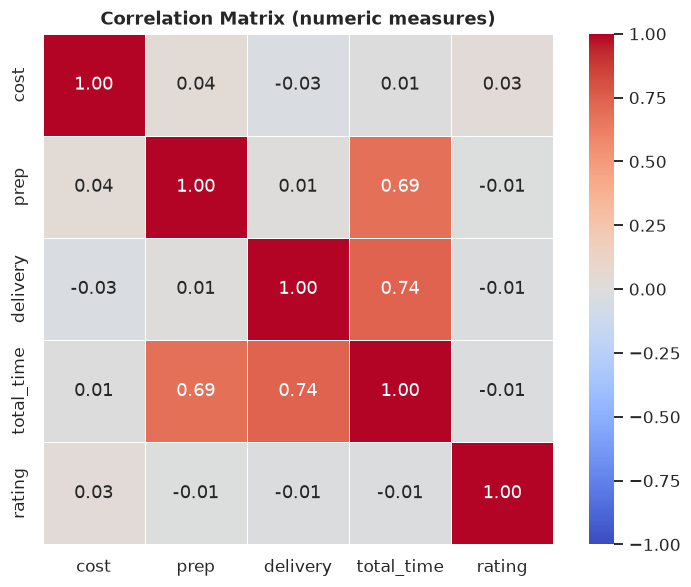

In [2]:
num = df[["cost_of_the_order","food_preparation_time","delivery_time",
          "total_fulfillment_time","rating_value"]].rename(columns={
          "cost_of_the_order":"cost","food_preparation_time":"prep",
          "delivery_time":"delivery","total_fulfillment_time":"total_time","rating_value":"rating"})
corr = num.corr()
fig, ax = plt.subplots(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=ax)
ax.set_title("Correlation Matrix (numeric measures)")
plt.tight_layout(); plt.show()

**Read-out:** Correlations among cost, prep, delivery and rating are all **near
zero** — these measures move essentially independently. The only strong values are the
mechanical ones (prep and delivery each correlate with `total_time` because they sum
to it). Crucially, **`rating` has ~0 correlation with time and cost**, reinforcing the
weak H2 signal seen earlier. No multicollinearity concerns among genuine predictors.

## 2. Fulfillment time by Day type AND Cuisine (H1 interaction)
Does the weekend-vs-weekday pattern hold across the major cuisines? Restricting to the
top cuisines keeps groups large enough to read.

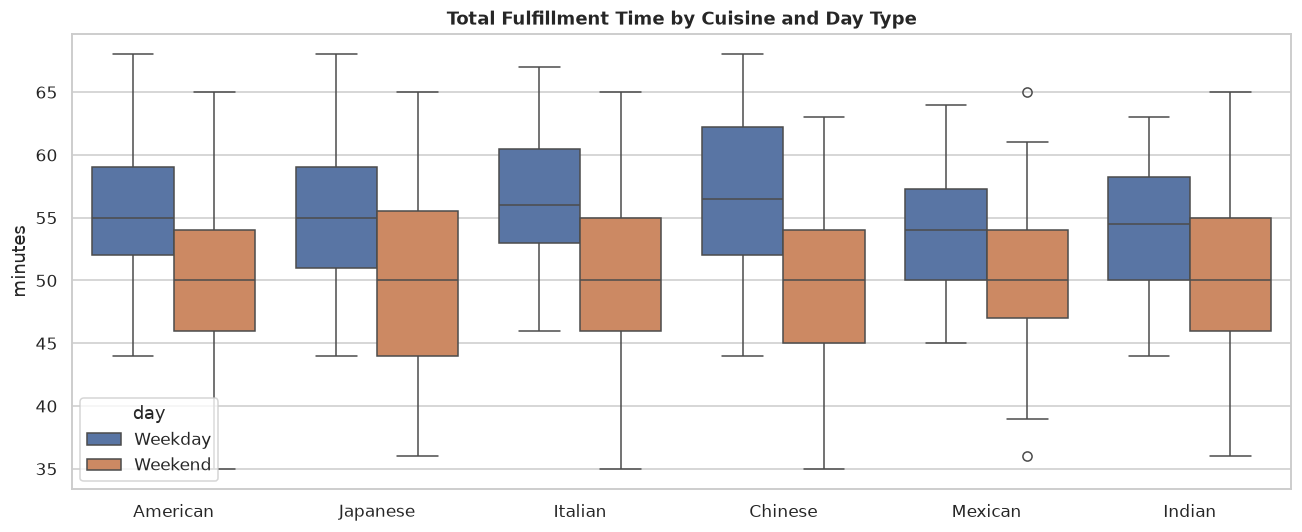

day_of_the_week  Weekday  Weekend
cuisine_type                     
American            55.7     50.0
Chinese             56.9     49.6
Indian              54.0     49.8
Italian             56.2     50.2
Japanese            55.4     50.1
Mexican             53.9     49.9


In [3]:
top_cuis = df["cuisine_type"].value_counts().head(6).index.tolist()
sub = df[df["cuisine_type"].isin(top_cuis)]
fig, ax = plt.subplots(figsize=(12,5))
sns.boxplot(data=sub, x="cuisine_type", y="total_fulfillment_time", hue="day_of_the_week",
            order=top_cuis, hue_order=["Weekday","Weekend"], palette=["#4C72B0","#DD8452"], ax=ax)
ax.set_title("Total Fulfillment Time by Cuisine and Day Type"); ax.set_xlabel(""); ax.set_ylabel("minutes")
ax.legend(title="day")
plt.tight_layout(); plt.show()

print(sub.groupby(["cuisine_type","day_of_the_week"], observed=True)["total_fulfillment_time"].mean().round(1).unstack())

**Read-out:** Within every major cuisine the **weekday and weekend boxes sit at
nearly the same level** — there is no cuisine where weekends are clearly slower. The
(small) day effect from H1 does **not** hide inside particular cuisines; it is
uniformly weak. Cuisine itself shifts the median only slightly.

## 3. Rating vs Fulfillment time, conditioned on Day type and Cost band (H2)
If speed mattered for ratings, we would expect a downward slope — here viewed across
sub-groups.

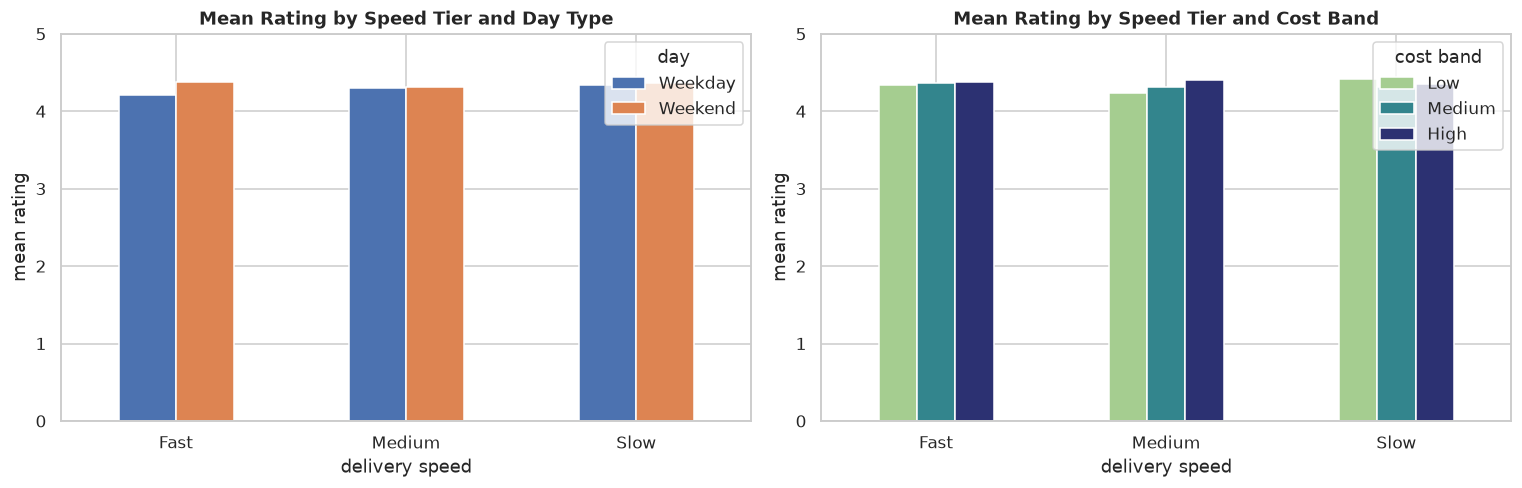

In [4]:
rated = df.dropna(subset=["rating_value"]).copy()
rated["rating_value"] = rated["rating_value"].astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14,4.6))
# 3a: mean rating across fulfillment-time tiers, split by day type
rated["time_tier"] = pd.qcut(rated["total_fulfillment_time"], 3, labels=["Fast","Medium","Slow"])
g = rated.groupby(["time_tier","day_of_the_week"], observed=True)["rating_value"].mean().unstack()
g.plot(kind="bar", ax=ax[0], color=["#4C72B0","#DD8452"])
ax[0].set_title("Mean Rating by Speed Tier and Day Type"); ax[0].set_ylabel("mean rating"); ax[0].set_xlabel("delivery speed")
ax[0].set_ylim(0,5); ax[0].legend(title="day"); ax[0].tick_params(axis="x", rotation=0)
# 3b: mean rating across speed tiers, split by cost band
g2 = rated.groupby(["time_tier","cost_band"], observed=True)["rating_value"].mean().unstack()
g2 = g2[["Low","Medium","High"]]
g2.plot(kind="bar", ax=ax[1], colormap="crest")
ax[1].set_title("Mean Rating by Speed Tier and Cost Band"); ax[1].set_ylabel("mean rating"); ax[1].set_xlabel("delivery speed")
ax[1].set_ylim(0,5); ax[1].legend(title="cost band"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Read-out:** Mean rating stays **flat (~4.3) across every speed tier**, and this
holds whether we split by day type or by cost band. No sub-group reveals a hidden
speed->rating or cost->rating effect. H2 looks weak even after conditioning on other
variables.

## 4. Cost x Volume x Cuisine (H3)
A bubble view: each cuisine positioned by order volume (x) and average cost (y), sized
by total revenue (volume x cost). Concentration should appear as a few large bubbles
far to the right.

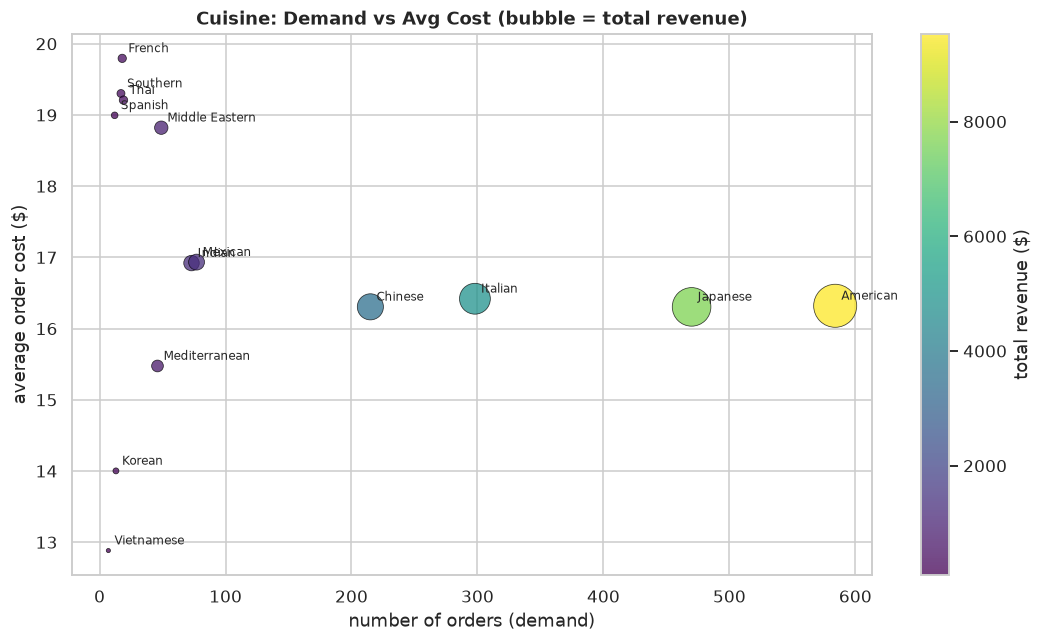

In [5]:
agg = df.groupby("cuisine_type").agg(orders=("order_id","count"),
        avg_cost=("cost_of_the_order","mean"),
        revenue=("cost_of_the_order","sum")).reset_index()
fig, ax = plt.subplots(figsize=(10,6))
sc = ax.scatter(agg["orders"], agg["avg_cost"], s=agg["revenue"]/12,
                c=agg["revenue"], cmap="viridis", alpha=0.75, edgecolor="black", linewidth=0.5)
for _, r in agg.iterrows():
    ax.annotate(r["cuisine_type"], (r["orders"], r["avg_cost"]), fontsize=8,
                xytext=(4,4), textcoords="offset points")
ax.set_xlabel("number of orders (demand)"); ax.set_ylabel("average order cost ($)")
ax.set_title("Cuisine: Demand vs Avg Cost (bubble = total revenue)")
plt.colorbar(sc, label="total revenue ($)")
plt.tight_layout(); plt.show()

**Read-out:** **Average cost per order is similar across cuisines** (bubbles sit
in a narrow vertical band ~\$15-18), so the horizontal axis — **order volume** — is
what separates them. American and Japanese are far to the right with the largest,
brightest bubbles: their revenue leadership is driven by **demand, not premium
pricing**. This is the multivariate confirmation of H3's concentration story.

## 5. Pairwise view across day type
A compact pairplot of the core numeric measures, colored by day type, to scan for any
multivariate structure at once.

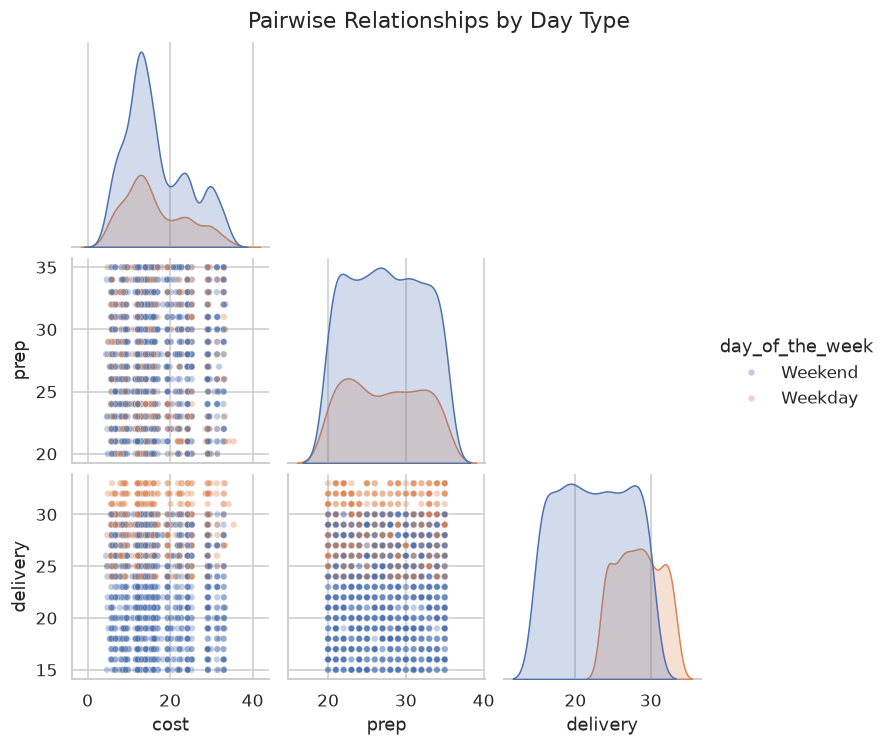

In [6]:
pp = df[["cost_of_the_order","food_preparation_time","delivery_time","day_of_the_week"]].rename(
     columns={"cost_of_the_order":"cost","food_preparation_time":"prep","delivery_time":"delivery"})
g = sns.pairplot(pp, hue="day_of_the_week", palette=["#4C72B0","#DD8452"],
                 plot_kws=dict(alpha=0.35, s=18), height=2.2, corner=True)
g.fig.suptitle("Pairwise Relationships by Day Type", y=1.02)
plt.show()

**Read-out:** The point clouds for weekday and weekend **overlap almost
completely** in every panel, and no pair of variables shows a clear linear or clustered
relationship. This visually corroborates the near-zero correlations: the numeric
measures are largely independent of one another and of day type.

## Multivariate summary (visual, pre-test)
- **Correlations are near zero** across cost, times, and rating (aside from the
  mechanical prep/delivery -> total).
- **H1:** no cuisine hides a weekend slowdown — the day effect is uniformly small.
- **H2:** rating stays flat across speed tiers even after conditioning on day/cost —
  weak association.
- **H3:** cuisine revenue is driven by **volume, not price** — a clear concentration
  pattern.

Consistent with the earlier views: expect H1 and H2 to be weak/null and H3 to hold.
No tests were run here, by design.